# Movimiento Browniano

In [2]:
import matplotlib.pyplot as plt

In [3]:
import torch 
import torch.distributions as dist
import math

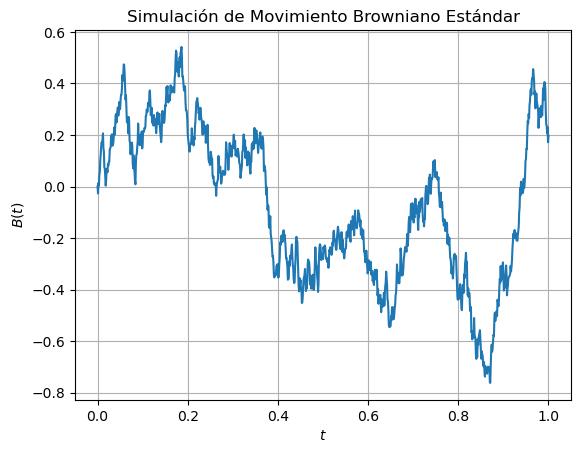

In [5]:
# Simlular Movimiento Browniano


class BrownianMotion:

    def __init__(self):
        self.B_t = None
        self.times = None

    def __call__(self, t = 1, partition_size = 100):
     
        delta = t / partition_size
        
        self.times = torch.arange(0, t + delta, delta)
 
        self.B_t = torch.zeros(self.times.shape[0]) 
        
        self.B_t[1:] = math.sqrt(delta) * dist.Normal(0.0, 1.0).sample((partition_size,)).cumsum(dim=0)

    def simulate_k (self, t = 1, partition_size = 100, k = 100):

        delta = t / partition_size
        
        times = torch.arange(0, t + delta, delta)
 
        B_t = torch.zeros((times.shape[0], k)) 
        
        B_t[1:, :] = math.sqrt(delta) * dist.Normal(0.0, 1.0).sample((partition_size, k)).cumsum(dim=0)

        return B_t, times

    def plot_k(self, t=1, partition_size=100, k=100):
        
        B_t, times = self.simulate_k(t, partition_size, k)
    
        plt.figure(figsize=(10, 6))
    
        plt.plot(times, B_t)
    
        plt.grid(True)
        plt.title(f"Simulación de {k} Movimientos Brownianos Estándar")
        plt.xlabel("$t$")
        plt.ylabel("$B(t)$")
    
        plt.show()
            

    def plot(self, t = 1, partition_size = 10):
        self(t, partition_size)
        plt.plot(self.times, self.B_t)
        plt.grid(True)
        plt.title("Simulación de Movimiento Browniano Estándar")
        plt.xlabel("$t$")
        plt.ylabel("$B(t)$")
        plt.show()


brow_mo = BrownianMotion()
brow_mo.plot(partition_size=1000) 


In [6]:
# Simular k Movimientos Brownianos
B_t, times = brow_mo.simulate_k(partition_size = 1000, k = 500000, t=10)

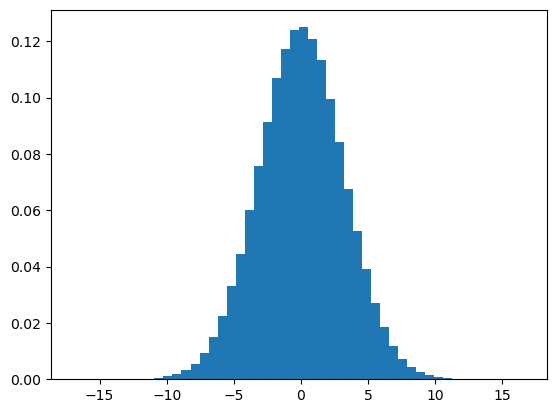

In [7]:
# Gráfica del histograma de los k Brownianos al tiempo t=10
plt.hist(B_t[-1, :], density=True, bins=50)
plt.show()

In [8]:
# Esperanza y Varianza
print('E(B_t): {:.4f}'.format(B_t[-1, :].mean().item()))
print('Var(B_t): {:.4f}'.format(B_t[-1, :].var().item()))

E(B_t): -0.0010
Var(B_t): 10.0246


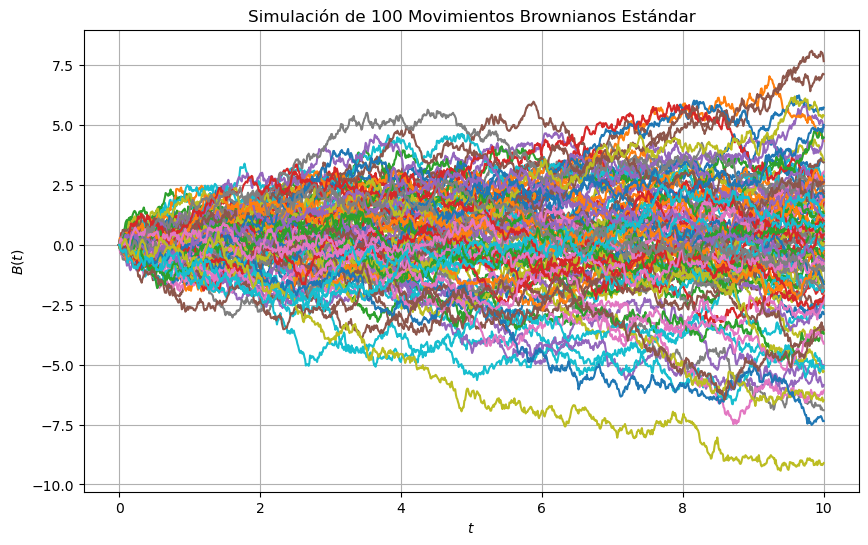

In [9]:
#
brow_mo.plot_k(partition_size = 1000, k = 100, t=10)

In [10]:
# Probabilidad de que el movimiento browniano supere la barrera a<0<b anted del tiempo t=10
b = 5.5
a = -3.5

Ind =  ((((B_t<a) | (B_t > b)).float()).sum(dim=0)>0).float()

prob_ab = Ind.mean().item()
print('Proba: {:.4f}'.format(prob_ab))

Proba: 0.3398


# Movimiento Browniano Geométrico :  $X_t = X_0 \exp(t(r-\sigma^2/2)+\sigma B(t))$

In [11]:
x_0 = 10.0 # Precio inicial
r = 0.05 # tasa libre de riesgo
sigma2 = 0.05 # Volatilidad

# MBG
X_t = x_0 * torch.exp((r - sigma2 / 2) * times[:, None] + math.sqrt(sigma2) * B_t)

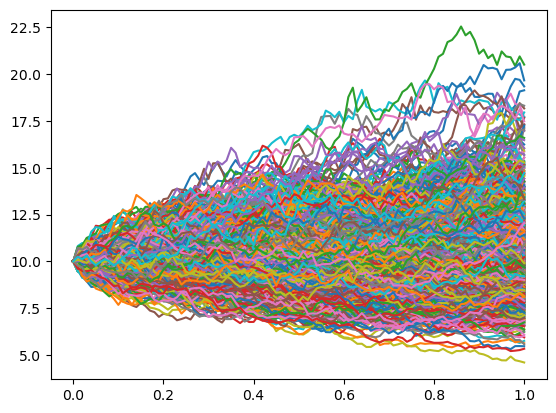

In [12]:
plt.plot(times[:101], X_t[:101, :1000])
plt.show()

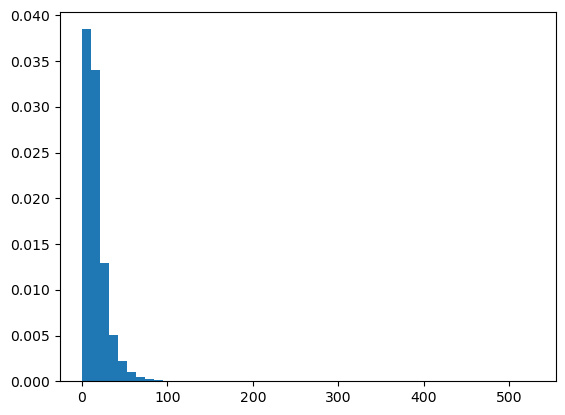

In [13]:
# Histograma dl proceso a tiempo t=10
plt.hist(X_t[-1, :], bins=50, density=True)
plt.show()

In [14]:
n = X_t[-1,:].shape[0]
EX_t = X_t[-1,:].mean().item()
VX_t = X_t[-1,:].var().item()
IC_EX_t = (EX_t - 1.96*math.sqrt(VX_t)/math.sqrt(n), EX_t + 1.96*math.sqrt(VX_t)/math.sqrt(n))
print('E(X(t)): {:.4f}'.format(EX_t))
print('V(X(t)): {:.4f}'.format(VX_t))
print('Intervalo del 95% para E(X(t)): ({:.4f}, {:.4f})'.format(IC_EX_t[0], IC_EX_t[1]))

E(X(t)): 16.4925
V(X(t)): 177.4112
Intervalo del 95% para E(X(t)): (16.4556, 16.5295)


# Proceso Poisson Compuesto

In [15]:
class CompoudPoissonProcess:

    def __init__(self, claims_dist ,rate = 1, ):

        self.rate = rate 
        self.claims_dist = claims_dist

    def simulate(self, t = 1):
        
        S_t = [0]
        X_t = [0]
        S = 0
        N = 0
        X = 0


        
        while S <= t :
            
            u = torch.rand((1,))
            T = -torch.log(u)/self.rate
            S += T.item()
            
            if S <= t:
                
                Y = self.claims_dist.sample((1,)).item()
                N += 1
                X +=Y
                S_t.append(S)
                X_t.append(X)
        

        S_t.append(t)
        N_t = list(range(len(S_t)))
        N_t[-1] = N 
        X_t.append(X_t[-1])
        
        return S_t, N_t, X_t

    def plot(self, t = 1):

        S_t, _ , X_t = self.simulate(t) 
        plt.step(S_t, X_t, where='post')
        plt.xlabel('$t$')
        plt.ylabel('$N(t)$')
        plt.title('Proceso de Poisson')
        plt.grid(True)
        plt.show()


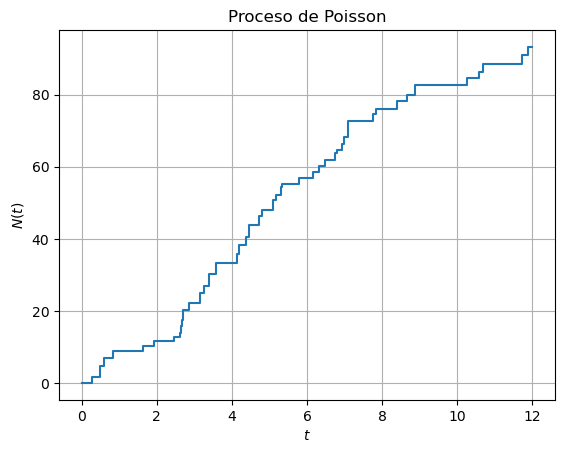

In [16]:
claims_dist = dist.Gamma(10,5)
com_poi_pro = CompoudPoissonProcess(claims_dist, rate = 4)
com_poi_pro.plot(t=12)

In [17]:
# Simular n poissones compuestos a tiempo t

n = 50000
t = 12

X_t = torch.empty((n,))
for i in range(n):
    X_t[i] = com_poi_pro.simulate(t=t)[2][-1]

In [20]:
print('Esperanza estimada: {:.4f}'.format(X_t.mean().item()))
print('Esperanza verdadera: {:.4f}'.format(com_poi_pro.rate * com_poi_pro.claims_dist.mean.item() * t))
print('Varianza estimada: {:.4f}'.format(X_t.var().item()))
print('Varianza Real: {:.4f}'.format(com_poi_pro.rate * t *( com_poi_pro.claims_dist.mean.item()**2 + 
                                                             com_poi_pro.claims_dist.variance.item() ) ))

Esperanza estimada: 95.8663
Esperanza verdadera: 96.0000
Varianza estimada: 210.1209
Varianza Real: 211.2000


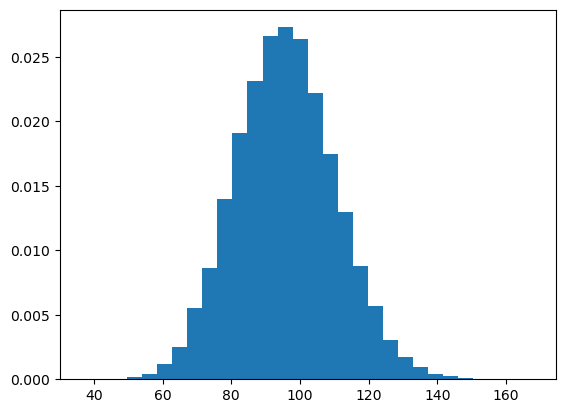

In [29]:
# histograma de X_t
plt.hist(X_t, bins=30, density=True)
plt.show()

# Monte Carlo Condicional

In [23]:
n = 100000
# Simulamos N_t
N_t = dist.Poisson(t*4).sample((n,))
# Simulamos X_t dado N_t
X_Nt = N_t * claims_dist.mean

In [24]:
print('Esperanza estimada: {:.4f}'.format(X_Nt.mean().item()))
print('Esperanza verdadera: {:.4f}'.format(com_poi_pro.rate * com_poi_pro.claims_dist.mean.item() * t))
print('Varianza estimada: {:.4f}'.format(X_Nt.var().item()))
print('Varianza Real: {:.4f}'.format(com_poi_pro.rate * t *( com_poi_pro.claims_dist.mean.item()**2) ))

Esperanza estimada: 96.0431
Esperanza verdadera: 96.0000
Varianza estimada: 193.1277
Varianza Real: 192.0000


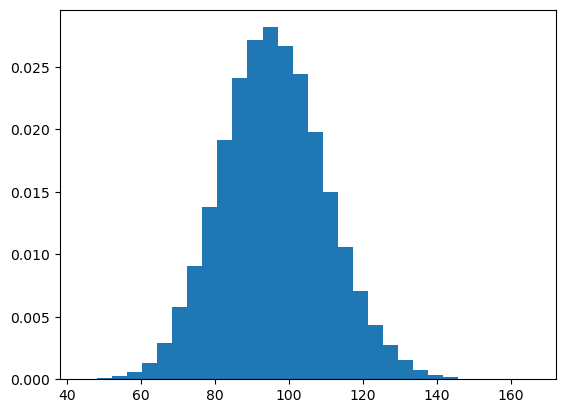

In [30]:
# Histograma X_t | N_t
plt.hist(X_Nt, bins=30, density=True)
plt.show()

# Bias Variance Trade-off

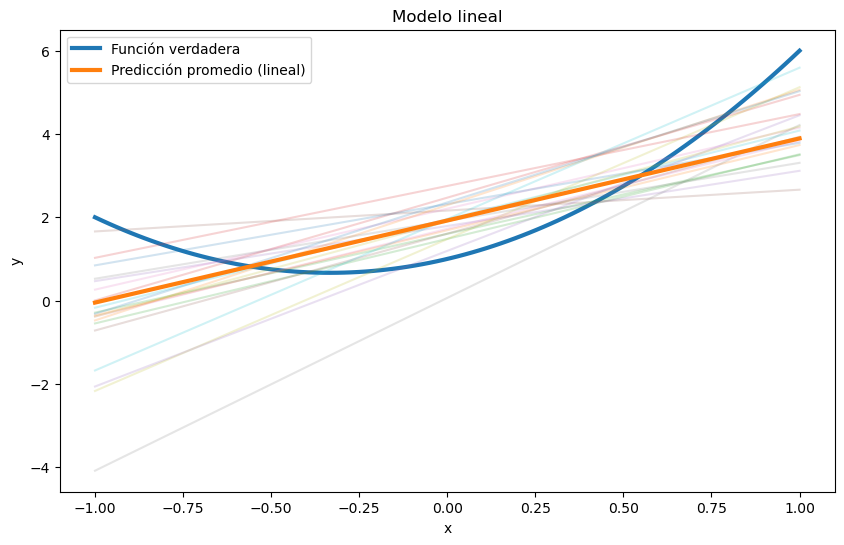

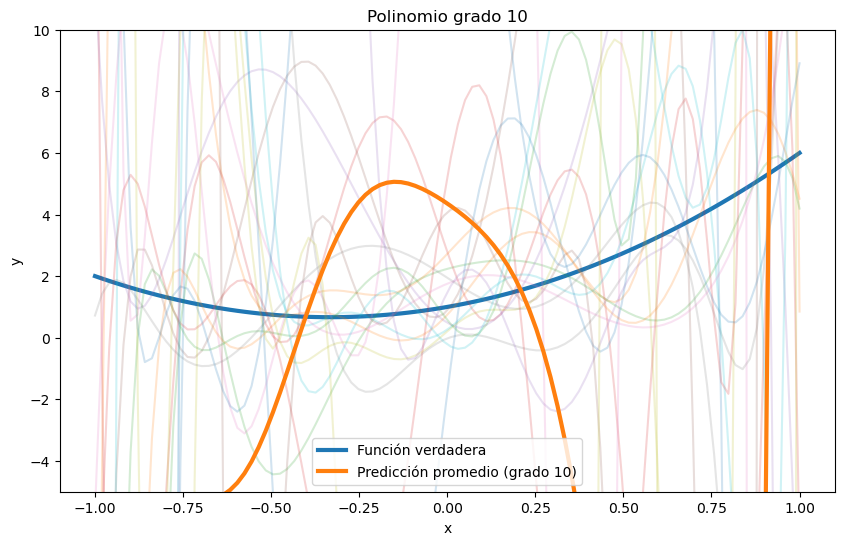

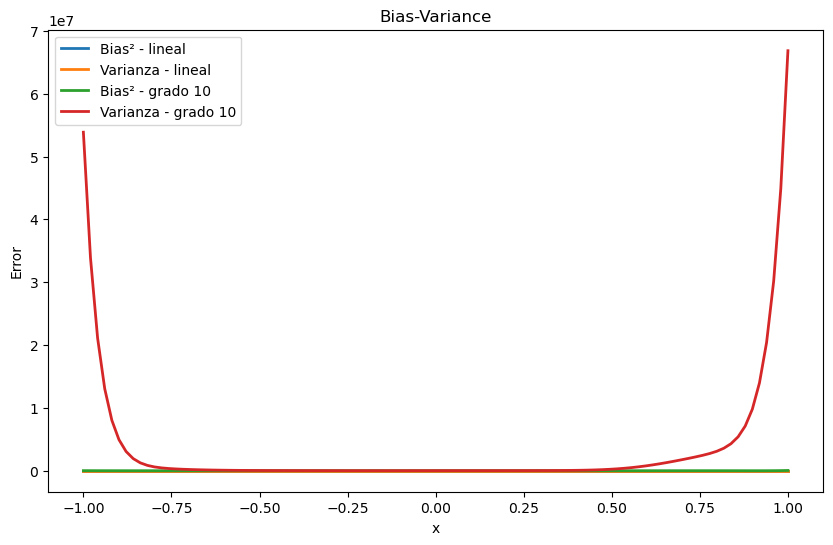

MODELO LINEAL
-----------------------------
Bias² promedio:    0.8421786427497864
Variance promedio: 0.5489174127578735
MSE promedio:      1.3910958766937256

POLINOMIO GRADO 10
-----------------------------
Bias² promedio:    1440.0712890625
Variance promedio: 3746469.75
MSE promedio:      3747909.5


In [4]:
torch.manual_seed(18081997)

# ============================================================
# 1. Función verdadera
# ============================================================

def f(x):
    return 1 + 2*x + 3*x**2


# ============================================================
# 2. Configuración de la simulación
# ============================================================

B = 1000       # número de muestras de entrenamiento
n = 10         # observaciones por muestra
sigma = 1.0    # desviación estándar del ruido

# Puntos donde queremos estudiar las predicciones
x_test = torch.linspace(-1, 1, 100)

# Valor verdadero de f(x)
y_true = f(x_test)


# ============================================================
# 3. Guardamos las predicciones de cada modelo
# ============================================================

pred_linear = torch.zeros(B, len(x_test))
pred_poly10 = torch.zeros(B, len(x_test))


# ============================================================
# 4. Repetimos el experimento B veces
# ============================================================

for b in range(B):

    # --------------------------------------------
    # Generar una nueva muestra de entrenamiento
    # --------------------------------------------

    x_train = 2 * torch.rand(n) - 1

    epsilon = sigma * torch.randn(n)

    y_train = f(x_train) + epsilon

    # --------------------------------------------
    # Modelo lineal
    # --------------------------------------------

    X_linear = torch.column_stack([
        torch.ones(n),
        x_train
    ])

    beta_linear = torch.linalg.lstsq(
        X_linear,
        y_train
    ).solution

    X_test_linear = torch.column_stack([
        torch.ones(len(x_test)),
        x_test
    ])

    pred_linear[b] = X_test_linear @ beta_linear

    # --------------------------------------------
    # Polinomio grado 10
    # --------------------------------------------

    X_poly10 = torch.stack(
        [x_train**j for j in range(11)],
        dim=1
    )

    beta_poly10 = torch.linalg.lstsq(
        X_poly10,
        y_train
    ).solution

    X_test_poly10 = torch.stack(
        [x_test**j for j in range(11)],
        dim=1
    )

    pred_poly10[b] = X_test_poly10 @ beta_poly10


# ============================================================
# 5. Predicción promedio
# ============================================================

mean_linear = pred_linear.mean(dim=0)
mean_poly10 = pred_poly10.mean(dim=0)


# ============================================================
# 6. Bias^2
# ============================================================

bias2_linear = (mean_linear - y_true)**2
bias2_poly10 = (mean_poly10 - y_true)**2


# ============================================================
# 7. Varianza
# ============================================================

variance_linear = ((pred_linear - mean_linear)**2).mean(dim=0)
variance_poly10 = ((pred_poly10 - mean_poly10)**2).mean(dim=0)


# ============================================================
# 8. Error cuadrático esperado
# ============================================================

mse_linear = ((pred_linear - y_true)**2).mean(dim=0)
mse_poly10 = ((pred_poly10 - y_true)**2).mean(dim=0)


# ============================================================
# 9. Gráfica de las predicciones
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x_test,
    y_true,
    linewidth=3,
    label="Función verdadera"
)

# Algunas de las curvas obtenidas
for b in range(20):
    plt.plot(
        x_test,
        pred_linear[b],
        alpha=0.2
    )

plt.plot(
    x_test,
    mean_linear,
    linewidth=3,
    label="Predicción promedio (lineal)"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Modelo lineal")
plt.legend()
plt.show()


# ============================================================
# 10. Polinomio grado 10
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x_test,
    y_true,
    linewidth=3,
    label="Función verdadera"
)

for b in range(20):
    plt.plot(
        x_test,
        pred_poly10[b],
        alpha=0.2
    )

plt.plot(
    x_test,
    mean_poly10,
    linewidth=3,
    label="Predicción promedio (grado 10)"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polinomio grado 10")
plt.legend()
plt.ylim(-5, 10)
plt.show()


# ============================================================
# 11. Bias² y Varianza
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x_test,
    bias2_linear,
    linewidth=2,
    label="Bias² - lineal"
)

plt.plot(
    x_test,
    variance_linear,
    linewidth=2,
    label="Varianza - lineal"
)

plt.plot(
    x_test,
    bias2_poly10,
    linewidth=2,
    label="Bias² - grado 10"
)

plt.plot(
    x_test,
    variance_poly10,
    linewidth=2,
    label="Varianza - grado 10"
)

plt.xlabel("x")
plt.ylabel("Error")
plt.title("Bias-Variance")
plt.legend()
plt.show()


# ============================================================
# 12. Promedios sobre todos los x
# ============================================================

print("MODELO LINEAL")
print("-----------------------------")
print("Bias² promedio:   ", bias2_linear.mean().item())
print("Variance promedio:", variance_linear.mean().item())
print("MSE promedio:     ", mse_linear.mean().item())


print("\nPOLINOMIO GRADO 10")
print("-----------------------------")
print("Bias² promedio:   ", bias2_poly10.mean().item())
print("Variance promedio:", variance_poly10.mean().item())
print("MSE promedio:     ", mse_poly10.mean().item())

f(x0) = 2.75

MODELO LINEAL
Predicción promedio: 2.9083476066589355
Bias²: 0.025073964148759842
Varianza: 0.46452459692955017

POLINOMIO GRADO 10
Predicción promedio: 16.920385360717773
Bias²: 200.79981994628906
Varianza: 224327.515625


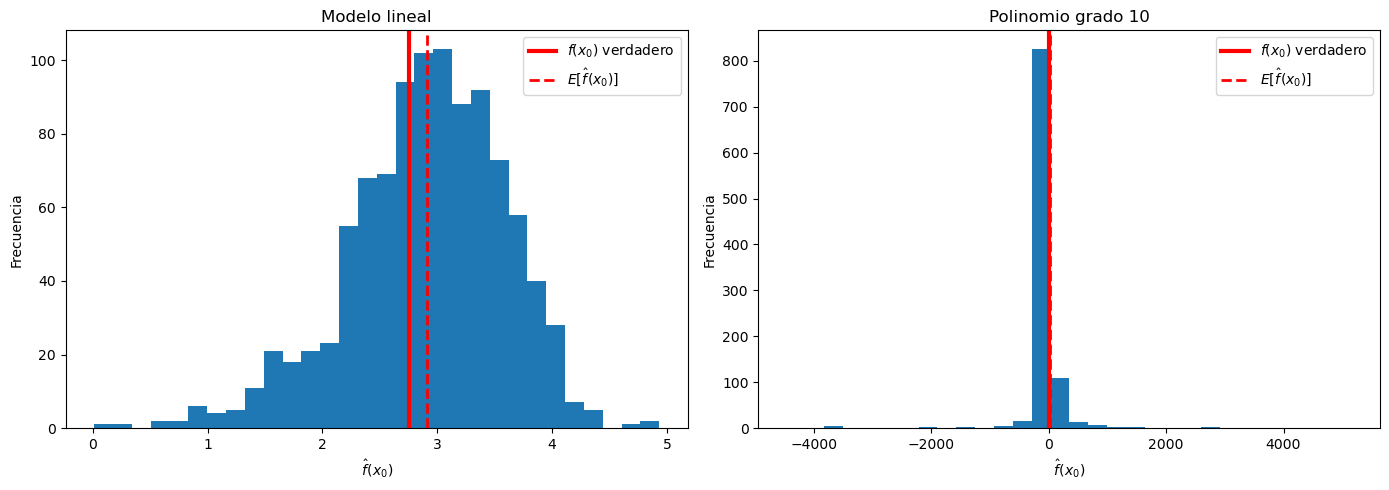

In [10]:
torch.manual_seed(18081997)


# ============================================================
# 1. Función verdadera
# ============================================================

def f(x):
    return 1 + 2*x + 3*x**2


# ============================================================
# 2. Parámetros
# ============================================================

B = 1000       # número de muestras de entrenamiento
n = 10         # observaciones por muestra
sigma = 1.0    # desviación estándar del ruido

x0 = torch.tensor(0.5)

# Verdadero valor de f(x0)
true_value = f(x0)

print("f(x0) =", true_value.item())


# ============================================================
# 3. Guardamos las predicciones
# ============================================================

pred_linear = torch.zeros(B)
pred_poly10 = torch.zeros(B)


# ============================================================
# 4. Simulación
# ============================================================

for b in range(B):

    # --------------------------------------------------------
    # Generamos una nueva muestra de entrenamiento
    # --------------------------------------------------------

    x_train = 2 * torch.rand(n) - 1

    epsilon = sigma * torch.randn(n)

    y_train = f(x_train) + epsilon


    # ========================================================
    # MODELO LINEAL
    # ========================================================

    X_linear = torch.column_stack([
        torch.ones(n),
        x_train
    ])

    beta_linear = torch.linalg.lstsq(
        X_linear,
        y_train
    ).solution

    x0_linear = torch.tensor([
        [1.0, x0.item()]
    ])

    pred_linear[b] = (
        x0_linear @ beta_linear
    ).squeeze()


    # ========================================================
    # POLINOMIO GRADO 10
    # ========================================================

    X_poly = torch.stack(
        [x_train**j for j in range(11)],
        dim=1
    )

    beta_poly = torch.linalg.lstsq(
        X_poly,
        y_train
    ).solution

    x0_poly = torch.tensor([
        [x0**j for j in range(11)]
    ])

    pred_poly10[b] = (
        x0_poly @ beta_poly
    ).squeeze()


# ============================================================
# 5. Bias y variance
# ============================================================

mean_linear = pred_linear.mean()
mean_poly10 = pred_poly10.mean()

bias2_linear = (mean_linear - true_value)**2
bias2_poly10 = (mean_poly10 - true_value)**2

variance_linear = (
    (pred_linear - mean_linear)**2
).mean()

variance_poly10 = (
    (pred_poly10 - mean_poly10)**2
).mean()


# ============================================================
# 6. Imprimir resultados
# ============================================================

print("\n==============================")
print("MODELO LINEAL")
print("==============================")

print("Predicción promedio:",
      mean_linear.item())

print("Bias²:",
      bias2_linear.item())

print("Varianza:",
      variance_linear.item())


print("\n==============================")
print("POLINOMIO GRADO 10")
print("==============================")

print("Predicción promedio:",
      mean_poly10.item())

print("Bias²:",
      bias2_poly10.item())

print("Varianza:",
      variance_poly10.item())


# ============================================================
# 7. Histogramas
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ------------------------------------------------------------
# Modelo lineal
# ------------------------------------------------------------

axes[0].hist(
    pred_linear.numpy(),
    bins=30
)

axes[0].axvline(
    true_value.item(),
    linewidth=3,
    label=r"$f(x_0)$ verdadero"
    ,color='r'
)

axes[0].axvline(
    mean_linear.item(),
    linestyle="--",
    linewidth=2,
    label=r"$E[\hat f(x_0)]$"
    ,color='r'
)

axes[0].set_title(
    "Modelo lineal"
)

axes[0].set_xlabel(
    r"$\hat f(x_0)$"
)

axes[0].set_ylabel(
    "Frecuencia"
)

axes[0].legend()


# ------------------------------------------------------------
# Polinomio grado 10
# ------------------------------------------------------------

axes[1].hist(
    pred_poly10.numpy(),
    bins=30
)

axes[1].axvline(
    true_value.item(),
    linewidth=3,
    label=r"$f(x_0)$ verdadero",
    color='r'
)

axes[1].axvline(
    mean_poly10.item(),
    linestyle="--",
    linewidth=2,
    label=r"$E[\hat f(x_0)]$"
    ,color='r'
)

axes[1].set_title(
    "Polinomio grado 10"
)

axes[1].set_xlabel(
    r"$\hat f(x_0)$"
)

axes[1].set_ylabel(
    "Frecuencia"
)

axes[1].legend()


plt.tight_layout()
plt.show()